In [20]:
from pathlib import Path

import dask.array as da
import numpy as np
import structlog
import xarray as xr

from climate_indices import indices, compute

In [21]:
logger = structlog.get_logger()

In [2]:
from dask.distributed import Client

client = Client(n_workers=4, threads_per_worker=2, memory_limit="4GB")
print("Dask dashboard available at:", client.dashboard_link)

2026-09-12T18:24:00.874727Z [info     ] To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy [distributed.http.proxy]
/Users/jadams/git/climate_indices/.venv/lib/python3.13/site-packages/distributed/node.py:195: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 51380 instead
  warnings.warn(
2026-09-12T18:24:00.884018Z [info     ] State start                    [distributed.scheduler]
2026-09-12T18:24:00.885014Z [info     ] Found stale lock file and directory '/var/folders/hh/4wqnt8ys3bb0v3h13gby1s680000gn/T/dask-scratch-space/scheduler-f9vqygwi', purging [distributed.diskutils]
2026-09-12T18:24:00.885422Z [info     ] Found stale lock file and directory '/var/folders/hh/4wqnt8ys3bb0v3h13gby1s680000gn/T/dask-scratch-space/scheduler-08t8c1uc', purging [distributed.diskutils]
2026-09-12T18:24:00.887063Z [info     ]   Scheduler at:     tcp://127.0.0.1:51

Dask dashboard available at: http://127.0.0.1:51380/status


2026-09-12T20:26:43.116722Z [error    ] Uncaught exception GET /workers/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:51380', method='GET', uri='/workers/ws', version='HTTP/1.1', remote_ip='127.0.0.1') [tornado.application]
╭───────────────────── Traceback (most recent call last) ──────────────────────╮
│ /Users/jadams/git/climate_indices/.venv/lib/python3.13/site-packages/tornado │
│ /websocket.py:965 in _accept_connection                                      │
│                                                                              │
│    962 │   │                                                                 │
│    963 │   │   self.start_pinging()                                          │
│    964 │   │   try:                                                          │
│ ❱  965 │   │   │   open_result = handler.open(*handler.open_args, **handler. │
│    966 │   │   │   if open_result is not None:                               │
│    967 │   │   │   │   aw

In [13]:
def clean_and_prepare_inputs(
    precip_path: Path,
    pet_path: Path,
    zarr_prepared_path: Path,
):
    """
    Loads raw datasets, standardizes structure, calculates water balance,
    and saves an optimized, rechunked Zarr store where time is contiguous.
    """
    print("Step 1: Cleaning and preparing datasets...")

    # Load lazily with Dask
    ds_precip = xr.open_dataset(precip_path, chunks={"time": 1, "lat": 500, "lon": 500})
    ds_pet = xr.open_dataset(pet_path, chunks={"time": 1, "lat": 500, "lon": 500})

    # Extract arrays and align coords
    pr = ds_precip["pr"]
    pet = ds_pet["pet"]

    # Ensure matching units (convert if necessary) and coordinates
    # For this example, assume they are pre-aligned and both in mm/month
    water_balance = pr - pet
    water_balance.name = "wb"

    # Create unified dataset
    ds_clean = xr.Dataset({"precip": pr, "wb": water_balance})

    # Critical Step: Rechunk so Time is continuous, Space is broken into blocks
    # This prevents Dask from performing expensive intermediate shuffles during fitting
    total_months = len(ds_clean.time)
    optimized_chunks = {"time": total_months, "lat": 100, "lon": 100}

    ds_rechunked = ds_clean.chunk(optimized_chunks)

    # Save to Zarr acting as our optimized analytics engine
    print(f"Saving optimized target structure to Zarr: {zarr_prepared_path}")
    try:
        ds_rechunked.to_zarr(zarr_prepared_path, mode="w")
    except Exception as e:
        raise RuntimeError("An unexpected error occurred:  ") from e
    else:
        print("Zarr dataset prepared successfully.")
    finally:
        print("finished")

In [33]:
# 2. Element-wise Wrapper Functions for climate_indices
def _spi_wrapper(
        precip_chunk,
        scale,
        distribution,
        data_start_year,
        calibration_start_year,
        calibration_end_year,
        periodicity: compute.Periodicity,
) -> np.ndarray:
    """
    Guaranteed to receive a numpy array with shape (time, lat, lon) where time is continuous,
    but lat and lon represent a subset block dictated by Dask.
    """
    # Allocate empty output matching input shape
    output = np.full(precip_chunk.shape, np.nan, dtype=np.float32)

    # Iterate over the spatial block slice passed to this worker
    for i in range(precip_chunk.shape[1]):
        for j in range(precip_chunk.shape[2]):
            time_series = precip_chunk[:, i, j]

            # Skip computation if entirely filled with NaNs (e.g., oceans)
            if np.isnan(time_series).all():
                continue

            output[:, i, j] = indices.spi(
                values=time_series,
                scale=scale,
                distribution=distribution,
                data_start_year=data_start_year,
                calibration_year_initial=calibration_start_year,
                calibration_year_final=calibration_end_year,
                periodicity=periodicity,
            )
    return output


def _spei_wrapper(
        precip_chunk,
        pet_chunk,
        scale,
        distribution,
        data_start_year,
        calibration_start_year,
        calibration_end_year,
        periodicity: compute.Periodicity,
) -> np.ndarray:
    """Wrapper for block-level SPEI calculation."""
    output = np.full(precip_chunk.shape, np.nan, dtype=np.float32)

    for i in range(precip_chunk.shape[1]):
        for j in range(precip_chunk.shape[2]):
            precip_time_series = precip_chunk[:, i, j]
            pet_time_series = pet_chunk[:, i, j]
            if np.isnan(precip_time_series).all():
                continue

            output[:, i, j] = indices.spei(
                precips_mm=precip_time_series,
                pet_mm=pet_time_series,
                scale=scale,
                distribution=distribution,
                data_start_year=data_start_year,
                calibration_year_initial=calibration_start_year,
                calibration_year_final=calibration_end_year,
                periodicity=periodicity,
            )
    return output

In [37]:
# 3. Concurrent Scaling Block Execution
def compute_indices_parallel(
    zarr_prepared_path: Path,output_zarr_path, config):
    """
    Loads the optimized Zarr cache, maps the index calculations concurrently across
    Dask workers via map_blocks, and outputs computed parameters cleanly.
    """
    print("\nStep 2: Executing parallelized SPI/SPEI workflows...")
    ds = xr.open_zarr(zarr_prepared_path)

    # Map the numpy wrappers using dask.array.map_blocks
    # map_blocks applies our function to every individual chunk block in parallel
    spi_array = da.map_blocks(
        _spi_wrapper,
        ds["precip"].data,
        scale=config["scale"],
        distribution=config["distribution_spi"],
        data_start_year=config["data_start_year"],
        calibration_start_year=config["cal_start_year"],
        calibration_end_year=config["cal_end_year"],
        periodicity=config["periodicty"],
        dtype=np.float32,
    )

    spei_array = da.map_blocks(
        _spei_wrapper,
        ds["precip"].data,
        ds["wb"].data,
        scale=config["scale"],
        distribution=config["distribution_spei"],
        data_start_year=config["data_start_year"],
        calibration_start_year=config["cal_start_year"],
        calibration_end_year=config["cal_end_year"],
        periodicity=config["periodicty"],
        dtype=np.float32,
    )

    # Wrap back into an Xarray Dataset retaining metadata and dimensions
    ds_output = xr.Dataset(
        data_vars={
            f"spi_{config['scale']}": (["time", "lat", "lon"], spi_array),
            f"spei_{config['scale']}": (["time", "lat", "lon"], spei_array)
        },
        coords=ds.coords
    )

    # Apply standard metadata attributes
    ds_output[f"spi_{config['scale']}"].attrs = {"long_name": "Standardized Precipitation Index",
                                                 "scale": config["scale"]}
    ds_output[f"spei_{config['scale']}"].attrs = {"long_name": "Standardized Precipitation Evapotranspiration Index",
                                                  "scale": config["scale"]}

    print(f"Triggering computation graph execution and streaming results into: {output_zarr_path}")
    # Computing and saving out natively streams block-by-block without using massive RAM overhead
    ds_output.to_zarr(output_zarr_path, mode="w")
    print("Parallel execution successfully finished!")

In [38]:
# Simulated execution configuration
pipeline_config = {
    "scale": 3,  # 3-Month SPI/SPEI
    "distribution_spi": indices.Distribution.gamma,
    "distribution_spei": indices.Distribution.pearson,
    "data_start_year": 1990,
    "cal_start_year": 1991,
    "cal_end_year": 2020,
    "periodicty": compute.Periodicity.monthly,
}

# File paths (Placeholders for real file strings)
precip_nc = "../data/e2e/raw_precipitation.nc"
pet_nc = "../data/e2e/raw_pet.nc"
prepared_zarr = "../data/e2e/cache_prepared_input.zarr"
final_output_zarr = "../data/e2e/climate_indices_output.zarr"

# print("To execute this script, replace file string placeholders with concrete file locations.")
clean_and_prepare_inputs(precip_nc, pet_nc, prepared_zarr)
# compute_indices_parallel(prepared_zarr, final_output_zarr, pipeline_config)

Step 1: Cleaning and preparing datasets...
Saving optimized target structure to Zarr: ../data/e2e/cache_prepared_input.zarr


/Users/jadams/git/climate_indices/.venv/lib/python3.13/site-packages/zarr/api/asynchronous.py:246: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Zarr dataset prepared successfully.
finished


In [39]:
compute_indices_parallel(prepared_zarr, final_output_zarr, pipeline_config)


Step 2: Executing parallelized SPI/SPEI workflows...
Triggering computation graph execution and streaming results into: ../data/e2e/climate_indices_output.zarr


/Users/jadams/git/climate_indices/.venv/lib/python3.13/site-packages/zarr/api/asynchronous.py:246: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
2026-09-12T19:56:49.942641Z [info     ] calculation_started            [climate_indices.indices] distribution=gamma index_type=spi input_elements=444 input_shape=(444,) scale=3
2026-09-12T19:56:49.942865Z [info     ] distribution_transform_started [climate_indices.compute] distribution=gamma input_shape='(37, 12)' operation=transform_fitted_gamma periodicity=monthly
2026-09-12T19:56:49.942990Z [info     ] distribution_fitting_started   [climate_indices.compute] calibration_period=1991-2020 distribution=gamma operation=gamma_parameters periodicity=monthly
2026-09-12T19:56:49.945127Z [info     ] distribution_fitting_completed [climate_indices.compute] calibration_period=1991-2020 distribution=gam

In [40]:
out_path = Path(final_output_zarr)

In [41]:
out_path

PosixPath('../data/e2e/climate_indices_output.zarr')

In [42]:
out_ds = xr.load_dataset(out_path)

In [43]:
out_ds

<xarray.Dataset> Size: 12MB
Dimensions:  (time: 444, lat: 38, lon: 87)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1980-01-01 1980-02-01 ... 2016-12-01
  * lat      (lat) float32 152B 24.56 25.23 25.9 26.56 ... 47.9 48.56 49.23
  * lon      (lon) float32 348B -124.7 -124.0 -123.4 ... -68.69 -68.02 -67.35
Data variables:
    spei_3   (time, lat, lon) float32 6MB nan nan nan nan ... nan nan nan nan
    spi_3    (time, lat, lon) float32 6MB nan nan nan nan ... nan nan nan nan

In [50]:
spi = out_ds['spi_3']
spei = out_ds['spei_3']

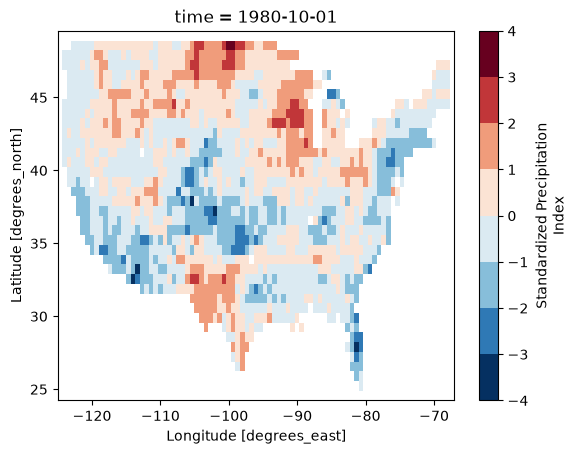

In [51]:
spi.isel(time=9).plot(
    levels=8,
)

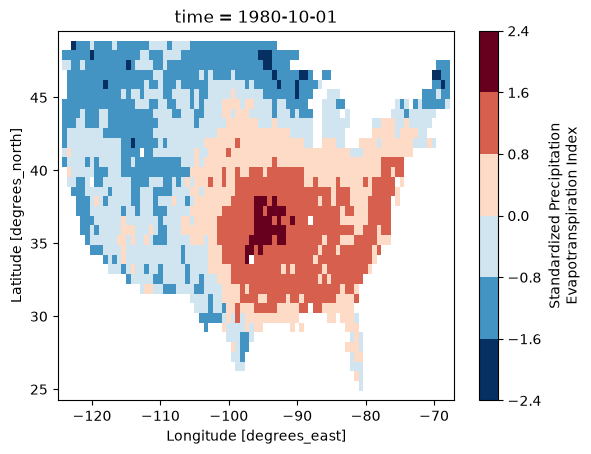

ERROR:tornado.application:Uncaught exception GET /workers/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:51380', method='GET', uri='/workers/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/Users/jadams/git/climate_indices/.venv/lib/python3.13/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/Users/jadams/git/climate_indices/.venv/lib/python3.13/site-packages/tornado/web.py", line 3415, in wrapper
    return method(self, *args, **kwargs)
  File "/Users/jadams/git/climate_indices/.venv/lib/python3.13/site-packages/bokeh/server/views/ws.py", line 167, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value for --session-token-expiration if necessary


In [52]:
spei.isel(time=9).plot(
    levels=8,
)